# 05 - Feature Engineering and Leakage Review

This notebook prepares the cleaned credit-risk dataset for modelling while documenting feature-use decisions.

The goal is not to maximize model performance yet. The goal is to create a defensible modelling dataset that a Canadian retail-risk analytics team could explain to business stakeholders, model validators, and governance reviewers.


## Professional framing

A credit default model can look strong for the wrong reason if it uses information observed after the prediction point. This notebook therefore separates:

1. **Baseline modelling features:** fields that can reasonably be available before the default outcome is known.
2. **Monitoring-only fields:** repayment fields that are useful for portfolio monitoring but risky for prediction.
3. **Fairness/proxy-sensitive fields:** variables retained for audit but excluded from the baseline model.
4. **High-cardinality encrypted fields:** variables that reduce explainability and are excluded from the first baseline model.

Encoding and imputation are intentionally deferred to the modelling pipeline in Notebook 06 so that transformations can be fit on the training split only.


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.append(str(PROJECT_ROOT / "src"))

from credit_risk.config import PROCESSED_DIR, TABLE_DIR
from credit_risk.features.engineering import (
    build_modeling_dataset,
    create_stratified_splits,
    feature_catalog,
    feature_missingness_by_split,
    save_feature_engineering_outputs,
    split_distribution,
)

CLEANED_PATH = PROCESSED_DIR / "credit_risk_cleaned.csv"
MODELING_PATH = PROCESSED_DIR / "credit_risk_modeling_dataset.csv"
CLEANED_PATH


WindowsPath('D:/Banking and Finance/Projects/canadian-retail-credit-risk-xai/data/processed/credit_risk_cleaned.csv')

## Load cleaned dataset

In [2]:
df = pd.read_csv(CLEANED_PATH, low_memory=False)

load_summary = {
    "row_count": df.shape[0],
    "column_count": df.shape[1],
    "record_key_duplicate_count": int(df.duplicated(["user_id", "record_sequence"]).sum()),
    "target_default_rate": float(df["defaulter"].mean()),
}
load_summary


{'row_count': 134417,
 'column_count': 46,
 'record_key_duplicate_count': 0,
 'target_default_rate': 0.0904126710163149}

The row count and record-key duplicate count should remain consistent with the previous notebooks. If this check fails, stop before modelling.

## Create model-ready raw features

The modelling dataset keeps identifiers for audit, keeps the target, and includes only baseline candidate features. It is **not one-hot encoded yet**. Notebook 06 will handle imputation, encoding, scaling, class imbalance, and model fitting inside scikit-learn pipelines.


In [3]:
modeling_df, feature_policy, numeric_features, categorical_features = build_modeling_dataset(df)
modeling_df["split"] = create_stratified_splits(modeling_df, random_state=42)

modeling_summary = {
    "modeling_rows": modeling_df.shape[0],
    "modeling_columns": modeling_df.shape[1],
    "numeric_feature_count": len(numeric_features),
    "categorical_feature_count": len(categorical_features),
    "target_default_rate": float(modeling_df["defaulter"].mean()),
    "record_key_duplicate_count": int(modeling_df.duplicated(["user_id", "record_sequence"]).sum()),
}
modeling_summary


{'modeling_rows': 134417,
 'modeling_columns': 51,
 'numeric_feature_count': 35,
 'categorical_feature_count': 12,
 'target_default_rate': 0.0904126710163149,
 'record_key_duplicate_count': 0}

## Feature-use policy

In [4]:
feature_policy.to_csv(TABLE_DIR / "feature_leakage_and_usage_policy.csv", index=False)

feature_policy_summary = (
    feature_policy.groupby("decision")
    .agg(feature_count=("feature", "count"))
    .reset_index()
    .sort_values("feature_count", ascending=False)
)
feature_policy_summary


,decision,feature_count
0,candidate_baseline_feature,48
1,exclude_from_baseline_model,13
2,exclude_from_model,2
3,target,1


In [5]:
excluded_features = feature_policy[feature_policy["decision"].str.contains("exclude", na=False)].copy()
excluded_features


,feature,dtype,decision,rationale
5,record_sequence,int64,exclude_from_model,Identifier or record key; useful for audit but...
0,user_id,int64,exclude_from_model,Identifier or record key; useful for audit but...
12,gender,object,exclude_from_baseline_model,Sensitive or proxy-sensitive field; retain for...
8,industry,object,exclude_from_baseline_model,High-cardinality or encrypted field; low inter...
22,interest_received,float64,exclude_from_baseline_model,Repayment/outcome-period information; useful f...
40,interest_to_amount_ratio,float64,exclude_from_baseline_model,Repayment/outcome-period information; useful f...
13,married,object,exclude_from_baseline_model,Sensitive or proxy-sensitive field; retain for...
38,payment_to_amount_ratio,float64,exclude_from_baseline_model,Repayment/outcome-period information; useful f...
16,pincode,object,exclude_from_baseline_model,Sensitive or proxy-sensitive field; retain for...
41,principal_exceeds_amount_flag,int64,exclude_from_baseline_model,Repayment/outcome-period information; useful f...


### Governance decision

The baseline model excludes repayment-derived variables because they may reflect behavior after the prediction point. It also excludes sensitive or proxy-sensitive fields such as gender, marital status, postal-code-like location, and social profile. These fields can be used later for fairness and reasonableness checks, but not for the first production-style baseline model.


## Baseline feature catalogue

In [6]:
catalog = feature_catalog(modeling_df, numeric_features, categorical_features)
catalog.to_csv(TABLE_DIR / "modeling_feature_catalog.csv", index=False)

print(f"Numeric features: {len(numeric_features)}")
print(f"Categorical features: {len(categorical_features)}")
display(catalog)


Numeric features: 35
Categorical features: 12


,feature,feature_type,dtype,missing_count,missing_pct,unique_values,included_in_baseline_model
0,amount_band,categorical,object,0,0.000000,6,True
1,dependents_band,categorical,object,0,0.000000,3,True
2,employment_type,categorical,object,0,0.000000,3,True
3,home,categorical,object,0,0.000000,4,True
4,income_band,categorical,object,0,0.000000,5,True
5,interest_rate_band,categorical,object,0,0.000000,4,True
6,is_verified,categorical,object,0,0.000000,4,True
7,loan_category,categorical,object,0,0.000000,7,True
8,loan_to_income_band,categorical,object,0,0.000000,6,True
9,tenure_band,categorical,object,0,0.000000,2,True


## Stratified train / validation / test split

Because there is no reliable observation date in the dataset, this project uses a stratified random split. In a real bank implementation, a time-based out-of-time validation set would be preferred when reliable application or performance dates are available.


In [7]:
split_summary = split_distribution(modeling_df)
split_summary.to_csv(TABLE_DIR / "modeling_split_distribution.csv", index=False)
split_summary


,split,row_count,row_pct,default_count,default_rate_pct
0,test,20163,15.000335,1823,9.041313
1,train,94091,69.999330,8507,9.041247
2,validation,20163,15.000335,1823,9.041313


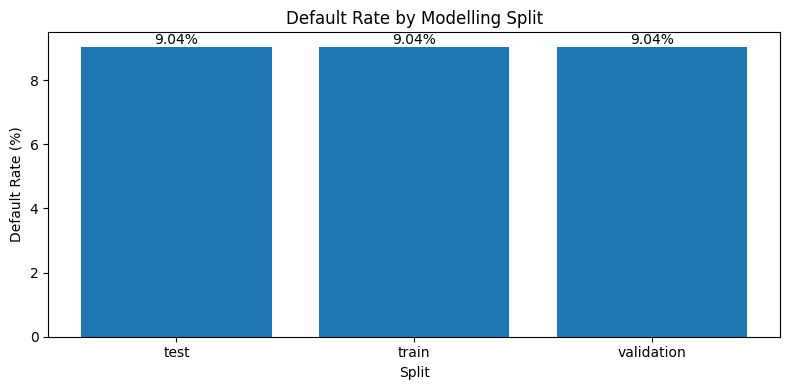

In [8]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(split_summary["split"], split_summary["default_rate_pct"])
ax.set_title("Default Rate by Modelling Split")
ax.set_xlabel("Split")
ax.set_ylabel("Default Rate (%)")
for idx, value in enumerate(split_summary["default_rate_pct"]):
    ax.text(idx, value, f"{value:.2f}%", ha="center", va="bottom")
plt.tight_layout()
plt.show()


The default rate should be nearly identical across train, validation, and test. This protects the modelling comparison from accidental target imbalance caused by the split.

## Missingness review for modelling features

Missing values are not filled here. Numeric imputation and categorical imputation will be handled inside Notebook 06 pipelines. This prevents validation/test information from leaking into the training transformation process.


In [9]:
missingness_by_split = feature_missingness_by_split(
    modeling_df,
    numeric_features + categorical_features,
)
missingness_by_split.to_csv(TABLE_DIR / "modeling_feature_missingness_by_split.csv", index=False)

missingness_top = (
    missingness_by_split
    .groupby("feature", as_index=False)
    .agg(max_missing_pct=("missing_pct", "max"))
    .sort_values("max_missing_pct", ascending=False)
)
missingness_top.head(15)


,feature,max_missing_pct
0,amount,20.779883
31,loan_to_income_ratio_log1p,20.779883
30,loan_to_income_ratio,20.779883
25,interest_rate_x_lti,20.779883
2,amount_log1p,20.779883
44,work_experience,0.000000
43,very_high_loan_to_income_flag,0.000000
26,is_verified,0.000000
27,is_verified_missing_flag,0.000000
28,loan_category,0.000000


## Save reusable feature-engineering artifacts

In [10]:
artifacts = save_feature_engineering_outputs(df, PROCESSED_DIR, TABLE_DIR, random_state=42)

print(f"Saved modelling dataset: {MODELING_PATH}")
print(f"Modelling dataset shape: {pd.read_csv(MODELING_PATH, nrows=5).shape[1]} columns")
{k: v.shape for k, v in artifacts.items()}


Saved modelling dataset: D:\Banking and Finance\Projects\canadian-retail-credit-risk-xai\data\processed\credit_risk_modeling_dataset.csv
Modelling dataset shape: 51 columns


{'modeling_dataset_preview': (10, 51),
 'feature_policy': (64, 4),
 'feature_catalog': (47, 7),
 'split_distribution': (3, 5),
 'feature_missingness_by_split': (141, 4)}

In [11]:
pd.read_csv(MODELING_PATH, low_memory=False).head()


,user_id,record_sequence,defaulter,amount,interest_rate,tenure_years,total_income_pa,dependents,delinq_2yrs,number_of_loans,...,work_experience,home,is_verified,interest_rate_band,loan_to_income_band,income_band,amount_band,dependents_band,tenure_band,split
0,7013527,1,1,55884.0,11.84,6,125000.0,4,0,0,...,1-2,Rent,Unknown,8%-12%,<=0.5,>120K,50K-100K,3+,6+ years,validation
1,7014291,1,0,55511.0,16.94,4,61000.0,1,0,0,...,10+,Mortgage,Source Verified,>16%,0.5-1.0,60K-90K,50K-100K,1-2,4-5 years,train
2,7014327,1,1,12289.0,11.84,6,100000.0,3,0,0,...,5-10,Own,Unknown,8%-12%,<=0.5,90K-120K,<=25K,3+,6+ years,train
3,7014304,1,0,29324.0,14.71,4,30000.0,1,0,0,...,2-3,Rent,Unknown,12%-16%,0.5-1.0,<=40K,25K-50K,1-2,4-5 years,train
4,7031995,1,0,30252.0,14.71,4,65000.0,3,0,0,...,10+,Rent,Verified,12%-16%,<=0.5,60K-90K,25K-50K,3+,4-5 years,test


## Notebook 05 conclusions

Carry these decisions forward into Notebook 06:

1. The baseline model will use the leakage-reviewed modelling dataset saved as `data/processed/credit_risk_modeling_dataset.csv`.
2. Repayment-derived variables are excluded from baseline modelling and retained only for monitoring/governance analysis.
3. Sensitive and proxy-sensitive fields are excluded from the baseline model but should be kept available for fairness review.
4. Imputation, encoding, scaling, resampling, and target encoding must be fit only on the training split or inside cross-validation folds.
5. Model selection should prioritize PR-AUC, recall, precision, F1, balanced accuracy, MCC, calibration, and business-cost trade-offs instead of accuracy alone.
